# Template File
Simple file for configurations ussage..

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

# Package Imports
from configurations import make_params_dict , save_fig, apply_general_styles , create_fig , set_font_sizes
from configurations.plot_config import FONTSIZES

#Plot Styles
apply_general_styles()


In [ ]:
# Plotting example
T_max = 5
A = 1.0
freq = 1.0
t = np.linspace(0, T_max, 100)
y = A * np.sin(2 * np.pi * freq * t)

# Create figure
set_font_sizes('normal')
fig, ax = create_fig()
ax.plot(t, y)
ax.set_title('Sine Wave')
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'Amplitude $x(t)$')

# Save figure
names = ['A', 'freq', 'T_max']
params = make_params_dict(names)
save_fig(fig, 'sine_wave', params=params, date=False, base_dir='../logs')


# Fist Steps for Dashboard

In [2]:
from tracklab import ExperimentReader
import pandas as pd
from omegaconf import OmegaConf


class ExperimentLoader:
    def __init__(self, experiment_name, base_dir="./data"):
        self.exp = ExperimentReader(experiment_name,base_dir)

    def list_runs(self):
        return self.exp.list_runs()

    def load_metrics(self, run_id):
        return self.exp.load_metrics(run_id)
    
    def load_config(self, run_id):
        return self.exp.load_config(run_id)
    
    def list_artifacts(self, run_id):
        return self.exp.list_artifacts(run_id)
    
def get_metric_all_runs(loader, metric_name):

    data = []

    for run_id in loader.list_runs():
        df = loader.load_metrics(run_id)
        df = df[df["metric"] == metric_name]
        df["run_id"] = run_id
        data.append(df)
    
    return pd.concat(data, ignore_index=True)

def get_metric_some_runs(loader, metric_name, list_runs,split="train"):

    data = []

    for run_id in list_runs:
        df = loader.load_metrics(run_id)
        df = df[df["metric"] == metric_name]
        df = df[df["split"] == split]
        df["run_id"] = run_id
        data.append(df)
    
    return pd.concat(data, ignore_index=True)

def plot_metric(df,ax,labels=None,colors=None):
    
    for run_id, group in df.groupby("run_id"):
        ax.plot(group["step"],group["value"],label=labels[run_id] if labels is not None else None,color=colors[run_id],lw=1.5)
    
    # ax.legend()
    # ax.set_xlabel("Steps")
    # ax.set_ylabel("Value")
    # ax.set_xscale("log")
    # return plt


init plot
end plot
Figure saved on /u/c/cerazova/InContextLearning/ICL/data/fix_data_uniform as fix_dataset_uniform.png


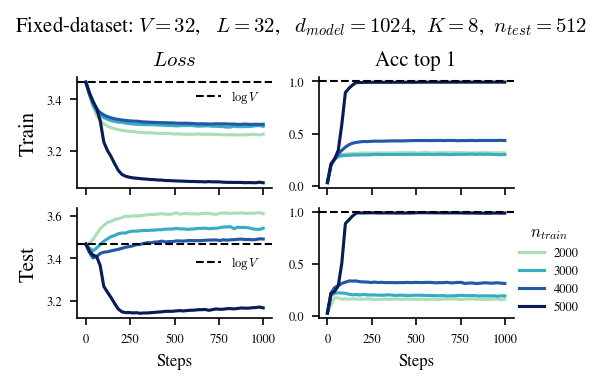

In [42]:
set_font_sizes(conf="tight")
loader = ExperimentLoader("fix_data_uniform", base_dir="../data")
metrics = ['loss_total','top1_accuracy','kl_b_total','kl_b_bigram'][:2]
titles = [r'$Loss$',r'Acc top 1',r'$D_{KL}(\pi_{b} | P_\theta^{(total)})$',r'$D_{KL}(\pi_b | P_\theta^{(bigram)})$'][:2]
list_runs = [1,2,3,4]
list_runs = [f'run_00{i}' for i in list_runs]

labels = {run_id:loader.load_config(run_id)['data_args']['batch_size'] for run_id in list_runs}
colors = plt.get_cmap("YlGnBu")(np.linspace(0.3,1,len(list_runs)))
colors = {run_id:colors[i] for i, run_id in enumerate(list_runs)}

fig , axs = create_fig(ncols=len(metrics),nrows=2, size="single",h=0.7,w=1.1)
print('init plot')
for j, split in enumerate(["train","test"]):
    axes = axs[j]
    for i, metric_name in enumerate(metrics):
        ax = axes[i]
        if i == 0:
            ax.set_ylabel(split.capitalize())
        if j==0: ax.set_title(titles[i])
        df = get_metric_some_runs(loader,metric_name,list_runs,split=split)
        # label = loader.load_config()
        plot_metric(df , ax, labels if i == 1 else None,colors)
        if j==1: ax.set_xlabel("Steps",size=FONTSIZES['s'])

    axes[0].axhline(np.log(32),color='k',ls='--',lw=1,label=r'$\log V$')    
    axes[0].legend(frameon=False)

    axes[1].axhline(1,color='k',ls='--',lw=1)
print('end plot')
ax.legend(title=r'$n_{train}$',loc=(1,0.),frameon=False)
# ax.set_xscale("log")
# Extra things

#clean handles and legends from axes[0]



cfg = loader.load_config(list_runs[0])
# title = rf"Online-Learning: $V = {cfg['model_args']['vocab_size']}$,   $L = {cfg['model_args']['seq_len']}$,   $d_{{model}} = {cfg['model_args']['d_model']}$,   $\pi_u = {cfg['data_args']['u_type']}$,   $\pi_b(i|j) = \pi_u(i)(1-\beta u_i u_j) $,   $\beta = {cfg['data_args']['beta']}$,   $K = {cfg['data_args']['K']}$"
title=rf"Fixed-dataset: $V = {cfg['model_args']['vocab_size']}$,   $L = {cfg['model_args']['seq_len']}$,   $d_{{model}} = {cfg['model_args']['d_model']}$,  $K = {cfg['data_args']['K']}$,  $n_{{test}} = {cfg['data_args']['test_size']}$"
fig.suptitle(title)

save_fig(fig, 'fix_dataset_uniform',base_dir="../data/fix_data_uniform")


In [ ]:
cfg = loader.load_config(list_runs[0],omega=True)
cfg.c

{'model_args': {'vocab_size': 32, 'seq_len': 32, 'd_model': 1024, 'rank': 2, 'dropout': 0.0, 'lin_attn': False}, 'optim_args': {'lr': 0.002, 'opt': 'adam', 'momentum': 0.9, 'weight_decay': 0.0}, 'data_args': {'b_type': 'spiked', 'alpha_d': 0.1, 'alpha_z': 1.0, 'u_type': 'zipf', 'beta': 0.8, 'fix_trig': True, 'trig_type': 'freq', 'batch_size': 256, 'test_size': 512, 'K': 6}, 'extra_args': {'total_steps': 1000, 'n_prints': 50, 'n_prints_model': 5, 'print_scale': 'linear', 'experiment_name': 'low_rank', 'file_name': 'results', 'path': 'full'}}